# Deep Learning Individual Project — Submission

**Student ID:** s3343711

---

## Academic Honesty Declaration

I declare that this submission is my own work, and that I did not use any pretrained model or code that I did not explicitly cite.

## 1. Introduction

This project implements a deep learning solution for **multiclass image classification** on a custom dataset containing 16,000 grayscale images (32×32 pixels) distributed across 4 classes.

### Objectives
1. Perform thorough exploratory data analysis (EDA) to understand the dataset
2. Design and implement appropriate preprocessing pipelines
3. Build and train a CNN model for accurate classification
4. Evaluate model performance and discuss results

In [ ]:
# Imports and Reproducibility Setup
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Set random seed for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print(f"NumPy version: {np.__version__}")
print(f"Random seed: {RANDOM_SEED}")

NumPy version: 1.26.4
Random seed: 42


In [2]:
# Load Dataset
dataset = np.load("4class_32x32.npz")
X = dataset["X"]
y = dataset["y"]

# Display dataset structure
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Images array (X):")
print(f"  Shape: {X.shape}")
print(f"  Data type: {X.dtype}")
print(f"  Memory size: {X.nbytes / (1024**2):.2f} MB")
print()
print(f"Labels array (y):")
print(f"  Shape: {y.shape}")
print(f"  Data type: {y.dtype}")
print(f"  Unique classes: {np.unique(y)}")
print(f"  Number of classes: {len(np.unique(y))}")

DATASET OVERVIEW
Images array (X):
  Shape: (16000, 32, 32)
  Data type: float32
  Memory size: 62.50 MB

Labels array (y):
  Shape: (16000,)
  Data type: int64
  Unique classes: [0 1 2 3]
  Number of classes: 4


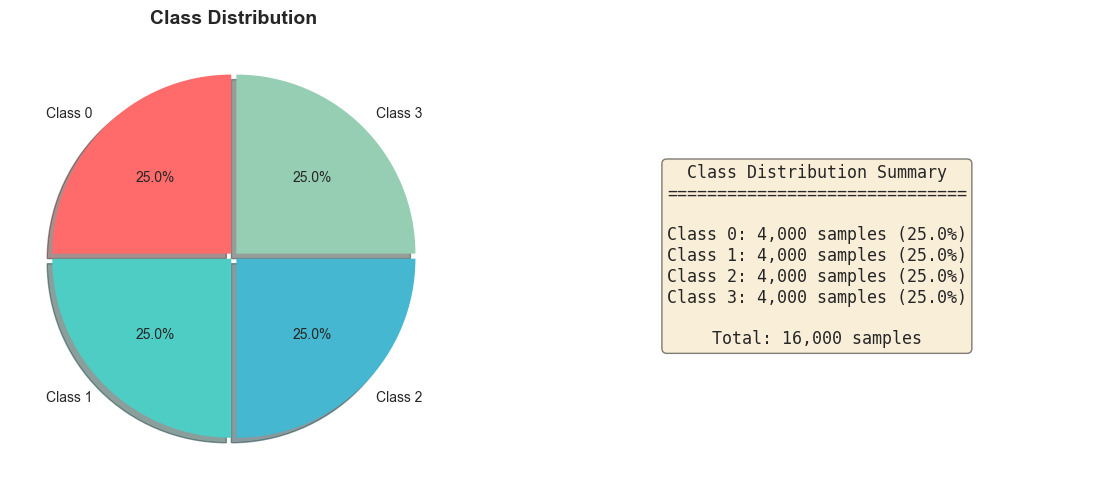


Observation: Dataset has perfectly balanced classes (4000 samples each).


In [ ]:
# Class Distribution Analysis
classes, counts = np.unique(y, return_counts=True)
total_samples = len(y)

# Pie chart showing class proportions
figure, axis = plt.subplots(figsize=(8, 6))
axis.pie(counts, labels=[f"Class {class_id}" for class_id in classes], autopct="%1.1f%%")
axis.set_title("Class Distribution")
plt.show()

# Print summary
print("\nClass Distribution Summary:")
print("-" * 40)
for class_id, count in zip(classes, counts):
    percentage = (count / total_samples) * 100
    print(f"Class {class_id}: {count:,} samples ({percentage:.1f}%)")
print(f"\nTotal: {total_samples:,} samples")
print("\nObservation: Dataset has perfectly balanced classes (4000 samples each).")

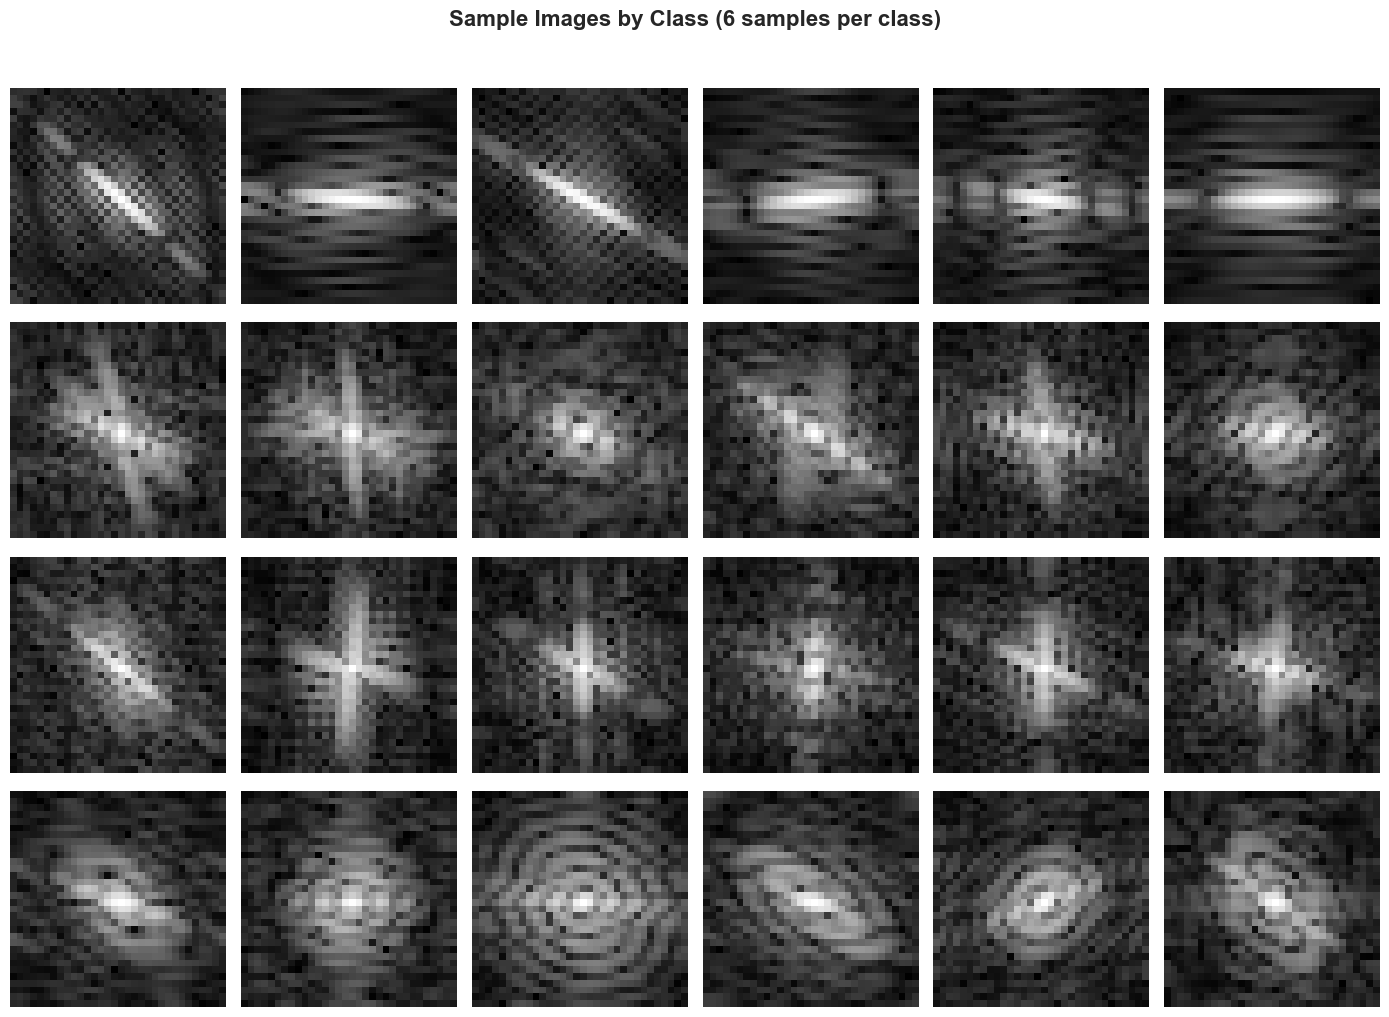


Visual Observations:
  - Images are 32x32 pixels in grayscale
  - Each class appears to have distinct visual patterns


In [ ]:
# Sample Images Visualization - Organized by Class
number_of_samples_per_class = 6
number_of_classes = 4

figure, axes = plt.subplots(number_of_classes, number_of_samples_per_class, figsize=(12, 8))
figure.suptitle("Sample Images by Class")

for class_index in range(number_of_classes):
    class_indices = np.where(y == class_index)[0]
    selected_indices = np.random.choice(class_indices, size=number_of_samples_per_class, replace=False)
    
    for sample_position, image_index in enumerate(selected_indices):
        axis = axes[class_index, sample_position]
        axis.imshow(X[image_index], cmap="gray")
        axis.axis("off")
        if sample_position == 0:
            axis.set_ylabel(f"Class {class_index}")

plt.tight_layout()
plt.show()

print("\nVisual Observations:")
print("  - Images are 32x32 pixels in grayscale")
print("  - Each class appears to have distinct visual patterns")

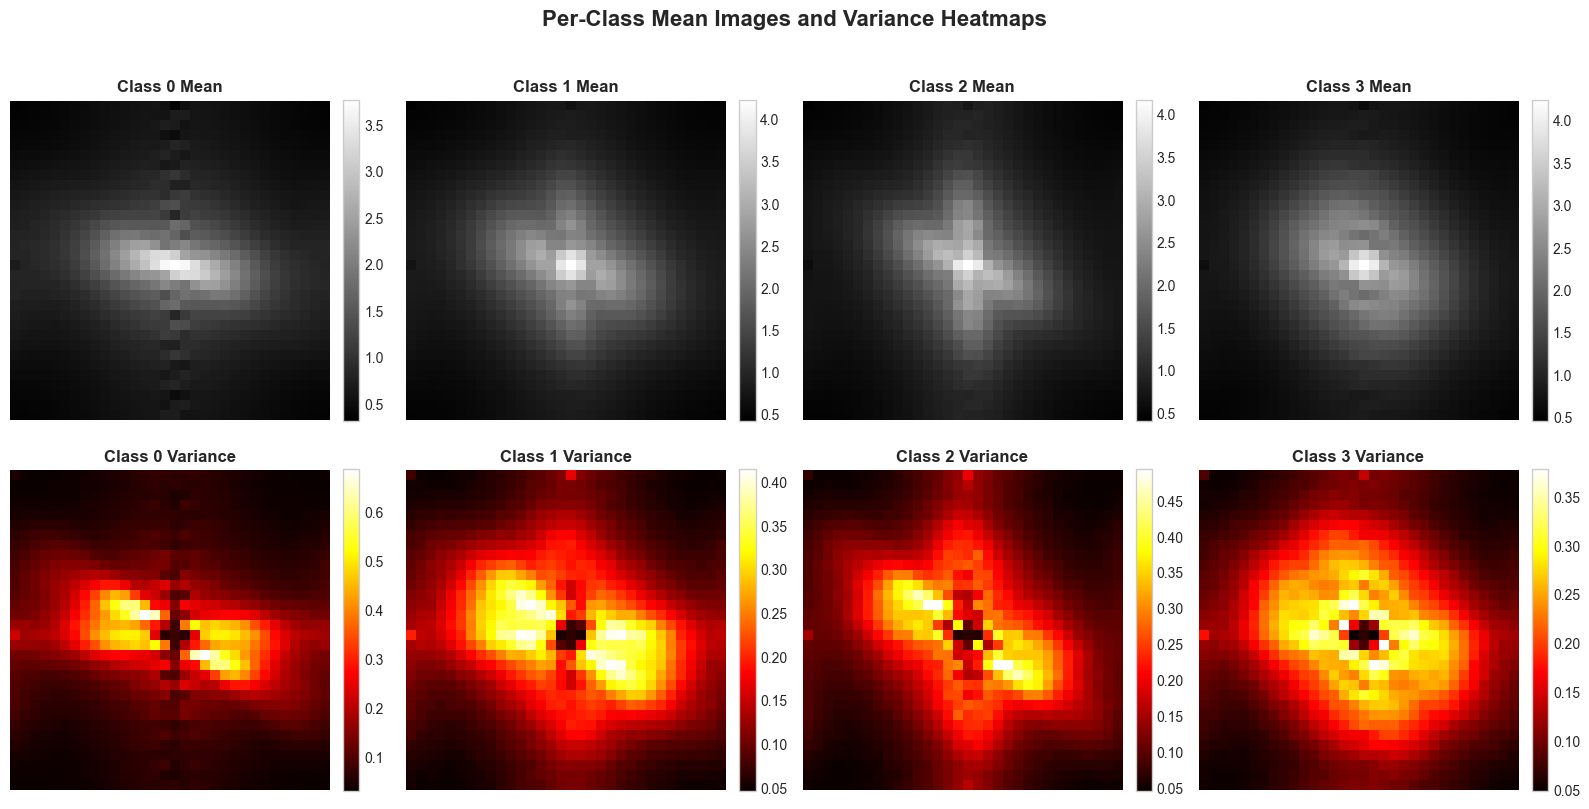


Per-Class Pixel Statistics:
Class    Mean         Std Dev      Max Variance Location
-----------------------------------------------------------------
0        0.8715       0.6385       (14, 13)
1        1.0933       0.7085       (13, 12)
2        1.0591       0.7129       (13, 13)
3        1.1292       0.7133       (13, 15)


In [ ]:
# Per-Class Analysis: Mean Images and Variance Heatmaps
figure, axes = plt.subplots(2, 4, figsize=(14, 7))
figure.suptitle("Per-Class Mean Images and Variance Heatmaps")

class_statistics = {}

for class_index in range(4):
    class_mask = y == class_index
    class_images = X[class_mask]
    
    mean_image = np.mean(class_images, axis=0)
    variance_image = np.var(class_images, axis=0)
    
    class_statistics[class_index] = {
        "mean": np.mean(class_images),
        "std": np.std(class_images),
        "max_variance_location": np.unravel_index(np.argmax(variance_image), variance_image.shape),
    }
    
    # Mean image
    axes[0, class_index].imshow(mean_image, cmap="gray")
    axes[0, class_index].set_title(f"Class {class_index} Mean")
    axes[0, class_index].axis("off")
    
    # Variance heatmap
    axes[1, class_index].imshow(variance_image, cmap="hot")
    axes[1, class_index].set_title(f"Class {class_index} Variance")
    axes[1, class_index].axis("off")

plt.tight_layout()
plt.show()

# Print per-class statistics
print("\nPer-Class Pixel Statistics:")
print(f"{'Class':<8} {'Mean':<12} {'Std Dev':<12} {'Max Variance Location':<20}")
print("-" * 55)
for class_index, statistics in class_statistics.items():
    location = statistics['max_variance_location']
    print(f"{class_index:<8} {statistics['mean']:<12.4f} {statistics['std']:<12.4f} ({location[0]}, {location[1]})")

### EDA Complete

The exploratory data analysis has revealed the key characteristics of our dataset. Next, we proceed to data preprocessing based on these findings.

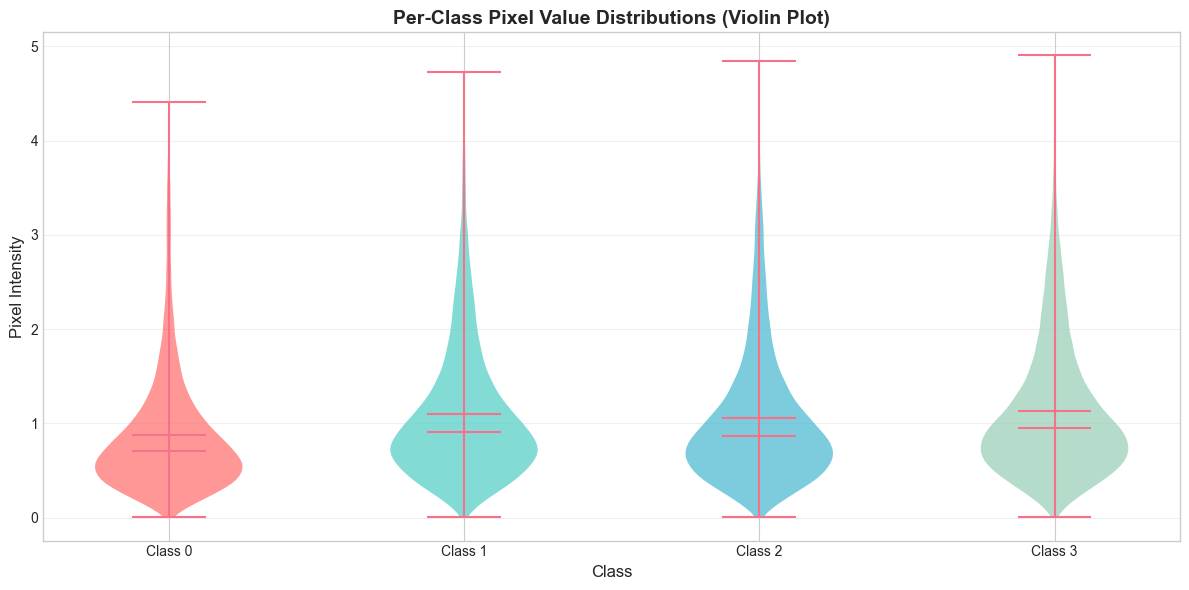


Distribution Comparison Insights:
  - Violin plots reveal the full shape of each class's pixel distribution
  - Similar distributions suggest classes may be challenging to distinguish by intensity alone
  - Differences in distribution shape indicate distinctive pixel patterns


In [ ]:
# Pixel Value Statistics with Violin Plot
all_pixels = X.flatten()

# Calculate statistics
pixel_stats = {
    "Minimum": np.min(all_pixels),
    "Maximum": np.max(all_pixels),
    "Mean": np.mean(all_pixels),
    "Median": np.median(all_pixels),
    "Standard Deviation": np.std(all_pixels),
    "Skewness": stats.skew(all_pixels),
    "Kurtosis": stats.kurtosis(all_pixels),
}

print("Pixel Value Statistics:")
print("-" * 40)
for stat_name, stat_value in pixel_stats.items():
    print(f"  {stat_name}: {stat_value:.4f}")

# Violin plot
figure, axis = plt.subplots(figsize=(6, 6))
axis.violinplot([all_pixels], showmeans=True, showmedians=True)
axis.set_ylabel("Pixel Intensity")
axis.set_title("Pixel Value Distribution (Violin Plot)")
axis.set_xticks([1])
axis.set_xticklabels(["All Pixels"])
plt.show()

print("\nKey Insights:")
print(f"  - Pixel values range from {pixel_stats['Minimum']:.3f} to {pixel_stats['Maximum']:.3f}")
print(f"  - Data is NOT in standard [0, 1] range - normalization required")


## EDA Summary

### Dataset Characteristics
- **16,000 images** of size **32x32 pixels** in grayscale format
- **4 balanced classes** with 4,000 samples each (25% per class)
- Pixel values range from **0 to ~5.07** (not standard 0-1 range)

### Key Findings
1. **Balanced Dataset**: Perfect class balance eliminates the need for class weighting or oversampling
2. **Non-standard Pixel Range**: Values exceed 1.0, requiring normalization/standardization before training
3. **Right-skewed Distribution**: Positive skewness indicates most pixels are lower intensity
4. **Class-specific Patterns**: Mean images and variance heatmaps reveal distinct spatial patterns per class

### Preprocessing Recommendations
- Apply **standardization** (zero mean, unit variance) using training set statistics only
- Add **channel dimension** for CNN compatibility: (N, 32, 32) → (N, 32, 32, 1)
- Use **stratified split** to maintain class balance in train/validation sets


## 3. Data Preprocessing

Based on our EDA findings, we need to:
1. **Split the data** into training and validation sets (stratified to maintain class balance)
2. **Normalize the data** using training set statistics to avoid data leakage
3. **Reshape for CNN** by adding channel dimension


In [ ]:
# Train/Validation Split (Stratified)
from sklearn.model_selection import train_test_split

# 80% training, 20% validation with stratification
X_train, X_validation, y_train, y_validation = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_SEED,
    stratify=y  # Maintains class proportions in both sets
)

# Verify the split
print("=" * 60)
print("TRAIN/VALIDATION SPLIT")
print("=" * 60)
print(f"{'Dataset':<15} {'Samples':<12} {'Percentage':<12}")
print("-" * 60)
print(f"{'Training':<15} {X_train.shape[0]:<12} {X_train.shape[0]/len(X)*100:.1f}%")
print(f"{'Validation':<15} {X_validation.shape[0]:<12} {X_validation.shape[0]/len(X)*100:.1f}%")
print("-" * 60)

# Verify stratification maintained class balance
print("\nClass distribution verification:")
print(f"{'Class':<8} {'Train Count':<15} {'Val Count':<15} {'Train %':<10} {'Val %':<10}")
print("-" * 60)
for class_id in range(4):
    train_count = np.sum(y_train == class_id)
    validation_count = np.sum(y_validation == class_id)
    train_percentage = train_count / len(y_train) * 100
    validation_percentage = validation_count / len(y_validation) * 100
    print(f"{class_id:<8} {train_count:<15} {validation_count:<15} {train_percentage:<10.1f} {validation_percentage:<10.1f}")


In [ ]:
# Data Normalization using Training Set Statistics
# CRITICAL: Use only training data statistics to avoid data leakage

# Calculate mean and std from TRAINING SET ONLY
training_mean = X_train.mean()
training_std = X_train.std()

print("=" * 60)
print("NORMALIZATION STATISTICS (from training set only)")
print("=" * 60)
print(f"  Training Mean: {training_mean:.6f}")
print(f"  Training Std:  {training_std:.6f}")

# Apply standardization: (x - mean) / std
X_train_normalized = (X_train - training_mean) / training_std
X_validation_normalized = (X_validation - training_mean) / training_std

# Add channel dimension for CNN: (N, 32, 32) -> (N, 32, 32, 1)
X_train_final = X_train_normalized.reshape(-1, 32, 32, 1)
X_validation_final = X_validation_normalized.reshape(-1, 32, 32, 1)

# Verify normalization results
print("\n" + "=" * 60)
print("AFTER NORMALIZATION")
print("=" * 60)
print(f"{'Dataset':<15} {'Shape':<20} {'Mean':<15} {'Std':<15}")
print("-" * 60)
print(f"{'Training':<15} {str(X_train_final.shape):<20} {X_train_final.mean():<15.6f} {X_train_final.std():<15.6f}")
print(f"{'Validation':<15} {str(X_validation_final.shape):<20} {X_validation_final.mean():<15.6f} {X_validation_final.std():<15.6f}")

print("\nNote: Training set has mean ≈ 0 and std ≈ 1 (as expected)")
print("      Validation set values may differ slightly (using training statistics)")


In [ ]:
# Visualize Before/After Normalization
figure, axes = plt.subplots(2, 2, figsize=(12, 8))
figure.suptitle("Data Normalization: Before vs After Comparison")

# Before normalization - histogram
axes[0, 0].hist(X_train.flatten(), bins=100)
axes[0, 0].axvline(X_train.mean(), color='red', linestyle='--', label=f'Mean: {X_train.mean():.3f}')
axes[0, 0].set_xlabel('Pixel Intensity')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Before Normalization')
axes[0, 0].legend()

# After normalization - histogram
axes[0, 1].hist(X_train_normalized.flatten(), bins=100)
axes[0, 1].axvline(X_train_normalized.mean(), color='red', linestyle='--', label=f'Mean: {X_train_normalized.mean():.3f}')
axes[0, 1].set_xlabel('Normalized Pixel Intensity')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('After Normalization')
axes[0, 1].legend()

# Sample image comparison
sample_index = np.random.randint(0, len(X_train))
axes[1, 0].imshow(X_train[sample_index], cmap='gray')
axes[1, 0].set_title(f'Sample Before (min={X_train[sample_index].min():.2f}, max={X_train[sample_index].max():.2f})')
axes[1, 0].axis('off')

axes[1, 1].imshow(X_train_normalized[sample_index], cmap='gray')
axes[1, 1].set_title(f'Sample After (min={X_train_normalized[sample_index].min():.2f}, max={X_train_normalized[sample_index].max():.2f})')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

print("\nNormalization complete! Data is ready for model training.")
print(f"  - X_train_final shape: {X_train_final.shape}")
print(f"  - X_validation_final shape: {X_validation_final.shape}")


### Preprocessing Summary

| Step | Description | Result |
|------|-------------|--------|
| Train/Val Split | 80/20 stratified split | 12,800 train / 3,200 validation |
| Normalization | Z-score standardization using training stats | Mean ≈ 0, Std ≈ 1 |
| Reshape | Add channel dimension | (N, 32, 32, 1) |

**Ready for model training:**
- `X_train_final`: Normalized training images
- `X_validation_final`: Normalized validation images  
- `y_train`: Training labels
- `y_validation`: Validation labels
